In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('bug_dataset_50k.csv')

In [3]:
df.columns

Index(['bug_id', 'title', 'description', 'error_code', 'bug_category',
       'bug_domain', 'tech_stack', 'severity', 'environment', 'developer_role',
       'root_cause', 'suggested_fix', 'explanation', 'created_at'],
      dtype='object')

In [4]:
df['created_at'] = pd.to_datetime(df['created_at'], errors = 'coerce')
df['mois'] = df['created_at'].dt.to_period('M')
df['error_code'] = (
    df.groupby(['severity', 'bug_category', 'tech_stack'])['error_code']
    .transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else x))
)

In [5]:
df['mois'].unique()

<PeriodArray>
['2025-04', '2025-07', '2025-05', '2025-09', '2025-08', '2025-06', '2026-01',
 '2025-12', '2025-10', '2025-03', '2025-11', '2025-02', '2026-02']
Length: 13, dtype: period[M]

In [6]:
# je crois qu'il soit plus interessant qu'on crée une variable pour chaque 3 mois
fv_ap_25 = df[df['mois'].astype(str).isin(['2025-02','2025-03','2025-04'])]
ma_jl_25 = df[df['mois'].astype(str).isin(['2025-05','2025-06','2025-07'])]
ag_ou_25 = df[df['mois'].astype(str).isin(['2025-08','2025-09','2025-10'])]
nv_jn_26 = df[df['mois'].astype(str).isin(['2025-11','2025-12','2026-01'])]

back_sys = df[df['bug_domain'] == 'Backend Systems']
mobile = df[df['bug_domain'] == 'Mobile']
data = df[df['bug_domain'] == 'Data']
web_dev = df[df['bug_domain'] == 'Web Development']
dev_ops = df[df['bug_domain'] == 'DevOps']
cloud = df[df['bug_domain'] == 'Cloud']



In [7]:
df['bug_domain'].unique()

array(['Mobile', 'Data', 'DevOps', 'Backend Systems', 'Web Development',
       'Cloud'], dtype=object)

In [8]:
df['bug_category'].unique()

array(['API Bug', 'Memory Leak', 'Cloud Configuration Bug',
       'Authentication Bug', 'Logging Bug', 'Frontend Routing Bug',
       'CI/CD Bug', 'UI Bug', 'Concurrency Bug', 'Monitoring Bug',
       'Performance Bug', 'Authorization Bug', 'Deployment Bug',
       'Backend Logic Bug', 'Database Bug', 'Security Vulnerability'],
      dtype=object)

In [9]:
data = [fv_ap_25,ma_jl_25,ag_ou_25,nv_jn_26] # 'DATA' DEVIENT NOTRE PRINCIPAL VARIABLE

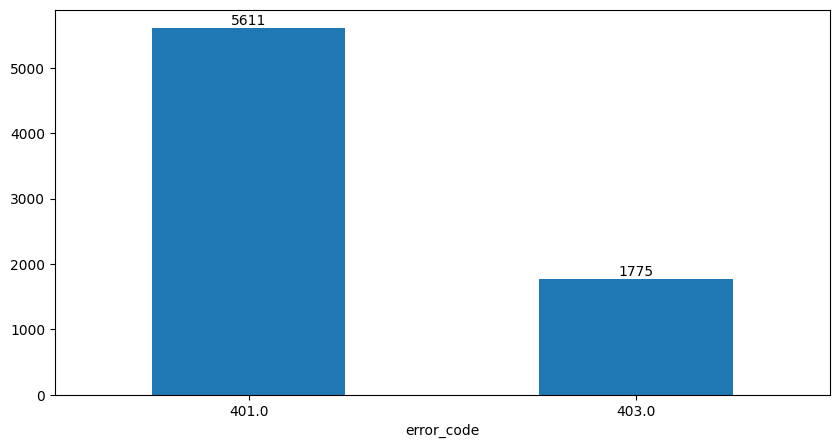

In [10]:
########ERROR_CODE###############
# Ici nous regroupons par le principal code d'erreur de chaque période
results_bug = []
for i in data :
    dt = i.groupby('error_code').size().sort_values(ascending = False).head(1)
    dt.dropna()
    results_bug.append(dt)
dt_errcd = pd.concat(results_bug)   
dt_errcd = dt_errcd.sort_values(ascending = False)
dt_errcd #ici nous avons les principaux bugs de chaque période

#Dans notre analyse, nous avons deux codes d’erreur principaux observés sur quatre périodes distinctes.
#Comme error_code est utilisé comme index, nous pouvons regrouper les lignes ayant le même index afin d’agréger les valeurs associées.
#L’utilisation de groupby(dt_errcd.index).sum() permet donc de calculer le total des occurrences pour chaque code d’erreur sur l’ensemble des périodes.
bug_c = (
    dt_errcd
    .groupby(dt_errcd.index)
    .sum()
)
bug_c
plt.figure(figsize = (10,5))
ax = bug_c.plot(kind = 'bar')
for i in ax.containers:
    ax.bar_label(i)
plt.xticks(rotation = 0)
plt.show()

<Figure size 1000x500 with 0 Axes>

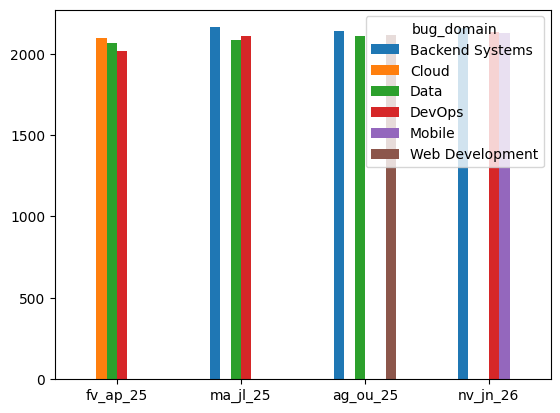

In [11]:
a = fv_ap_25.groupby('bug_domain').size().astype(int).sort_values(ascending = False).head(3)
b = ma_jl_25.groupby('bug_domain').size().astype(int).sort_values(ascending = False).head(3)
c = ag_ou_25.groupby('bug_domain').size().astype(int).sort_values(ascending = False).head(3)
d = nv_jn_26.groupby('bug_domain').size().astype(int).sort_values(ascending = False).head(3)
dt_bug_dm = pd.DataFrame({
    'fv_ap_25': a,
    'ma_jl_25': b,
    'ag_ou_25': c,
    'nv_jn_26': d
})
dt_bug_dm
dt_bug_dm = dt_bug_dm.T
dt_bug_dm = dt_bug_dm.fillna(0)
dt_bug_dm
plt.figure(figsize = (10,5))
dt_bug_dm.plot(kind = 'bar')
plt.xticks(rotation = 0)
plt.show()

In [12]:
df

,bug_id,title,description,error_code,bug_category,bug_domain,tech_stack,severity,environment,developer_role,root_cause,suggested_fix,explanation,created_at,mois
0,BUG_000001,API Bug detected in system,This issue relates to a api bug occurring in t...,403.0,API Bug,Mobile,Spring Boot,High,Development,Full-Stack Developer,Misconfiguration or logic issue related to api...,Review and fix the api bug according to best p...,This bug requires a full-stack developer due t...,2025-04-07,2025-04
1,BUG_000002,Memory Leak detected in system,This issue relates to a memory leak occurring ...,500.0,Memory Leak,Data,GCP,Medium,Production,Backend Developer,Misconfiguration or logic issue related to mem...,Review and fix the memory leak according to be...,This bug requires a backend developer due to i...,2025-07-04,2025-07
2,BUG_000003,Cloud Configuration Bug detected in system,This issue relates to a cloud configuration bu...,404.0,Cloud Configuration Bug,DevOps,Django,Medium,Production,Mobile Developer,Misconfiguration or logic issue related to clo...,Review and fix the cloud configuration bug acc...,This bug requires a mobile developer due to it...,2025-05-02,2025-05
3,BUG_000004,Authentication Bug detected in system,This issue relates to a authentication bug occ...,404.0,Authentication Bug,Backend Systems,Flask,Medium,Production,Mobile Developer,Misconfiguration or logic issue related to aut...,Review and fix the authentication bug accordin...,This bug requires a mobile developer due to it...,2025-07-03,2025-07
4,BUG_000005,Logging Bug detected in system,This issue relates to a logging bug occurring ...,503.0,Logging Bug,Mobile,Flask,High,Staging,Backend Developer,Misconfiguration or logic issue related to log...,Review and fix the logging bug according to be...,This bug requires a backend developer due to i...,2025-09-09,2025-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,BUG_049996,CI/CD Bug detected in system,This issue relates to a ci/cd bug occurring in...,500.0,CI/CD Bug,DevOps,Vue,Critical,Staging,Security Engineer,Misconfiguration or logic issue related to ci/...,Review and fix the ci/cd bug according to best...,This bug requires a security engineer due to i...,2025-11-17,2025-11
49996,BUG_049997,Memory Leak detected in system,This issue relates to a memory leak occurring ...,500.0,Memory Leak,Web Development,MySQL,High,Production,Frontend Developer,Misconfiguration or logic issue related to mem...,Review and fix the memory leak according to be...,This bug requires a frontend developer due to ...,2025-11-18,2025-11
49997,BUG_049998,Database Bug detected in system,This issue relates to a database bug occurring...,403.0,Database Bug,Data,AWS,Low,Production,Data Engineer,Misconfiguration or logic issue related to dat...,Review and fix the database bug according to b...,This bug requires a data engineer due to its n...,2025-09-26,2025-09
49998,BUG_049999,Authentication Bug detected in system,This issue relates to a authentication bug occ...,404.0,Authentication Bug,Cloud,AWS,High,Development,Security Engineer,Misconfiguration or logic issue related to aut...,Review and fix the authentication bug accordin...,This bug requires a security engineer due to i...,2025-05-03,2025-05


In [13]:
tec_ma_jl_25 = (
    nv_jn_26
    .groupby(['severity','tech_stack'])
    .size()
    .sort_values(ascending = False)
)
sv = nv_jn_26['severity'].unique()
r = []
for i in sv:
    g = tec_ma_jl_25.loc[i].head(3)
    r.append(g)
    print(i)
svr = pd.DataFrame(r)

High
Critical
Low
Medium


In [14]:
svr

tech_stack,Spring Boot,MongoDB,AWS,Laravel,Vue,Angular,React,Node.js,Azure,Kubernetes,GCP
0,220.0,219.0,217.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,241.0,228.0,213.0,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,240.0,223.0,215.0,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,216.0,215.0,215.0


In [15]:
svr_ = svr.set_index(sv).fillna(0)
svr_

tech_stack,Spring Boot,MongoDB,AWS,Laravel,Vue,Angular,React,Node.js,Azure,Kubernetes,GCP
High,220.0,219.0,217.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Critical,0.0,0.0,241.0,228.0,213.0,0.0,0.0,0.0,0.0,0.0,0.0
Low,0.0,0.0,0.0,0.0,0.0,240.0,223.0,215.0,0.0,0.0,0.0
Medium,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,216.0,215.0,215.0


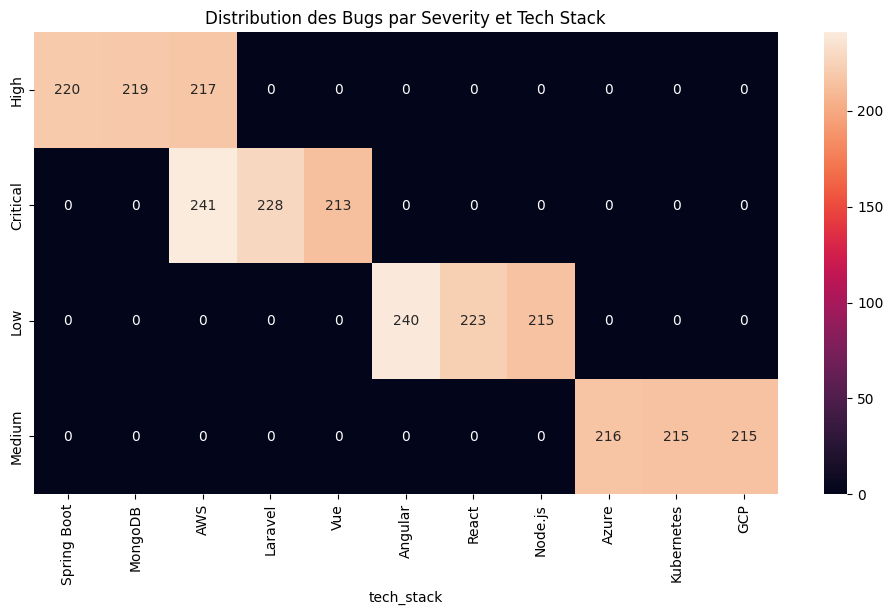

In [19]:
plt.figure(figsize=(12,6))
sns.heatmap(svr_, annot=True, fmt=".0f")# ce graphique est interessant, nous devons étudier seaborn
plt.title("Distribution des Bugs par Severity et Tech Stack")
plt.show()

In [23]:
df.groupby('severity').size().sort_values(ascending = False)

severity
Low         12628
High        12535
Critical    12432
Medium      12405
dtype: int64